# Return-on-Invested-Capital Premium — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · the ROIC-vs-ROE-vs-gross-profitability contrast · a 12-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Adds over ROE%2FGP%3F: No](https://img.shields.io/badge/Adds_over_ROE%2FGP%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **ROIC = NOPAT / invested capital is a cleaner, unlevered quality gauge than ROE and sorts future returns** — is tested on a survivor mega-cap panel, alongside the sharper question: *does the unlevered refinement add anything over plain ROE ([200](../../200-roe-quality/)) and gross profitability ([122](../../122-gross-profitability/))?*

> ⚠️ **Data note.** EDGAR `OperatingIncomeLoss` (→ TTM NOPAT), `StockholdersEquity`, `LongTermDebtNoncurrent`, `CashAndCashEquivalentsAtCarryingValue` + yfinance adjusted closes, 32 valid names, ends 2009-06-27 → 2026-05-29, as-of 2026-06-30. Point-in-time on the **filing date**. Survivorship named on the Signal axis. A flat 21% tax rate is a common scalar — **invariant to the sort**. Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `030498da471a`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from roic_premium import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 32, 'n_names_basket': 44, 'n_events': 844, 'end_lo': '2009-06-27', 'end_hi': '2026-05-29', 'fp_prices': '030498da471a', 'n_months': 202, 'avg_n': 16.5, 'ls_span_lo': '2009-09-30', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 13.5, 'ls_ann': 1.62, 'ls_t_iid': 0.48, 'ls_t_nw': 0.4, 'ls_sharpe': 0.12, 'ls_hit': 50, 'ls_long_bps': 179.3, 'ls_short_bps': 165.8, 'ls_turn': 0.06, 'ls120_mean_bps': 37.2, 'ls120_t_nw': 1.12, 'chg_mean_bps': 32.1, 'chg_t_nw': 1.14, 'chg_sharpe': 0.28, 'chg_n': 189, 'drift': {21: (840, 1.23, 0.96, 0.27, 0.47, 50, 0.3096), 63: (818, 4.94, 4.58, 0.37, 0.29, 51, 0.3615), 126: (811, 8.37, 10.05, -1.68, -0.85, 51, 0.8228)}, 'mono63': (4.58, 5.0, 4.94), 'era_early_n': 100, 'era_early_bps': -5.6, 'era_early_t': -0.14, 'era_late_n': 102, 'era_late_bps': 32.2, 'era_late_t': 0.6, 'contrast': {'roic': (13.5, 0.4, 0.12, 202), 'roic_chg': (32.1, 1.14, 0.28, 189), 'roe': (-65.5, -1.36, -0.5, 89), 'gp': (-164.1, -1.59, -0.85, 60)}, 'roic_roe_rank_corr': 0.752, 'net': {(10, 50): (8.1, 0.98, 0.24, 0.07), (20, 100): (2.8, 0.33, 0.08, 0.02)}, 'syn_null_mean': -0.38, 'syn_null_sd': 1.43, 'syn_null_fire': 2, 'syn_null_seeds': 12, 'syn_planted_bps': 825.4, 'syn_planted_t': 23.63}


real cache present: True | events: 844 | names: 32


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short **+13.5 bps/mo** (+1.6%/yr gross), one-sample *t* = +0.48, **Newey-West *t* = +0.40**; best specs (staleness-120 +1.12, ROIC-change +1.14) still ≪ 2; event drift flat & sign-flipping |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: NW *t* = +0.08, Sharpe 0.02; fails **before** costs |
| **Adds over ROE/GP?** | `NO` | ROIC NW *t* +0.40 vs ROE -1.36 vs GP -1.59 (both negative); ROIC↔ROE rank corr +0.75 |

> 💡 In plain words: on mega-cap survivors the quality premium is **absent**, ROIC included; the unlevered refinement is the least-bad of a losing set and largely the same bet as ROE.

## 1 · The claim, formalised

For name $i$ at fiscal quarter $q$, filed on date $F_{i,q}$:

$$\text{NOPAT}_{i,q} = \text{OpInc}^{\text{TTM}}_{i,q}\,(1-\tau), \qquad \text{IC}_{i,q} = \text{Debt}_{i,q} + \text{Equity}_{i,q} - \text{Cash}_{i,q}, \qquad \text{ROIC}_{i,q} = \frac{\text{NOPAT}_{i,q}}{\text{IC}_{i,q}}.$$

- **H₁ (sorts returns).** A cross-sectional long-short on $\text{ROIC}$ earns a positive forward spread.
- **H₂ (adds value).** $\text{ROIC}$'s spread beats plain ROE and gross profitability on the same panel.
- **H₃ (tradable).** Any spread survives realistic long-short costs + borrow.

The flat $\tau = 0.21$ is a **common scalar**: $(1-\tau)$ multiplies every name's NOPAT identically, so the cross-sectional ROIC *ranking* — and every long-short number — is invariant to it (only reported magnitudes move). We find **H₁ rejected** (NW *t* = +0.40), **H₂ rejected** (ROIC is the least-bad of a losing set), and therefore **H₃ moot**.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, because balance-sheet signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names in the cross-section. The pooled event drift + a **label-shuffle placebo** is the cross-check; the ROIC-vs-ROE-vs-GP contrast answers the value-add question on the identical panel.

## 3 · How we'd know — the protocol

- **Panel.** 844 (ticker, filing) balance-sheet quarters across 32 valid names (of 44), ends 2009-06-27 → 2026-05-29, each stamped with its 10-Q/10-K filing date (point-in-time).
- **Primary.** Monthly tercile long-short on `roic`, one execution lag (rank at month $M$ close, earn month $M{+}1$); Newey-West + one-sample *t*, Sharpe, hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, top-minus-bottom tercile, one-sample *t* + 10k-draw label-shuffle placebo, and the tercile monotonicity picture.
- **Robustness.** Staleness 120 vs 200 days; the ROIC-**change** variant; an era split at 2018 (the TCJA statutory-rate change).
- **Value-add.** The same long-short on `roic` vs `roe` (200) vs `gp` (122), plus the ROIC↔ROE cross-sectional rank correlation.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic panel, planted-premium knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh ROIC signals into terciles each month, long top / short bottom equal-weight, earn next month's return. The decisive statistic is the HAC *t* of the monthly long-short series.

calendar long-short: +13.5 bps/mo (+1.62%/yr gross), n=202 months, avg cross-section 16.5
  one-sample t = +0.48   Newey-West(6) t = +0.40   Sharpe 0.12   hit 50%   turnover 0.06
  ROIC-change variant: +32.1 bps/mo, NW t = +1.14, Sharpe 0.28


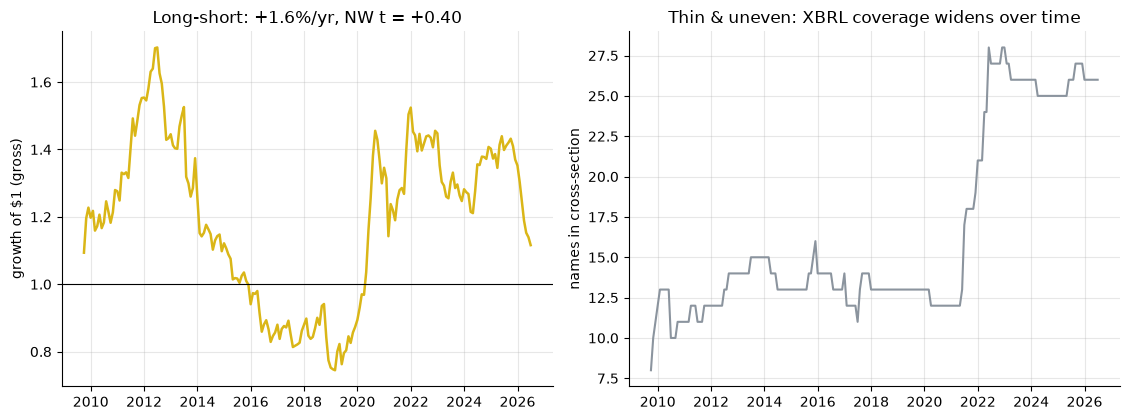

frozen: +13.5 bps/mo, NW t = +0.40, staleness-120 NW t = +1.12, ROIC-change NW t = +1.14


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='roic', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ls_chg = st.calendar_ls(PX, EV, signal_col='roic_chg', n_buckets=3, min_names=6, staleness_days=200)
    s_chg = st.calendar_ls_stats(ls_chg)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo (+{s['ann_pct']:.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  ROIC-change variant: {s_chg['mean_bps']:+.1f} bps/mo, NW t = {s_chg['t_nw']:+.2f}, Sharpe {s_chg['sharpe']:.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=AMBER, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: +{R['ls_ann']:.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: XBRL coverage widens over time')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}, ROIC-change NW t = {R['chg_t_nw']:+.2f}")

> 💡 In plain words: **+14 bps/month** is a rounding error (~+1.6%/yr gross), and the HAC *t* is **+0.40** — the monthly returns are indistinguishable from zero (n=202, avg cross-section 16). Every specification agrees: staleness-120 NW *t* = +1.12, ROIC-change NW *t* = +1.14. Right-signed by a hair, never remotely certified.

### 4b · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by ROIC; top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder.

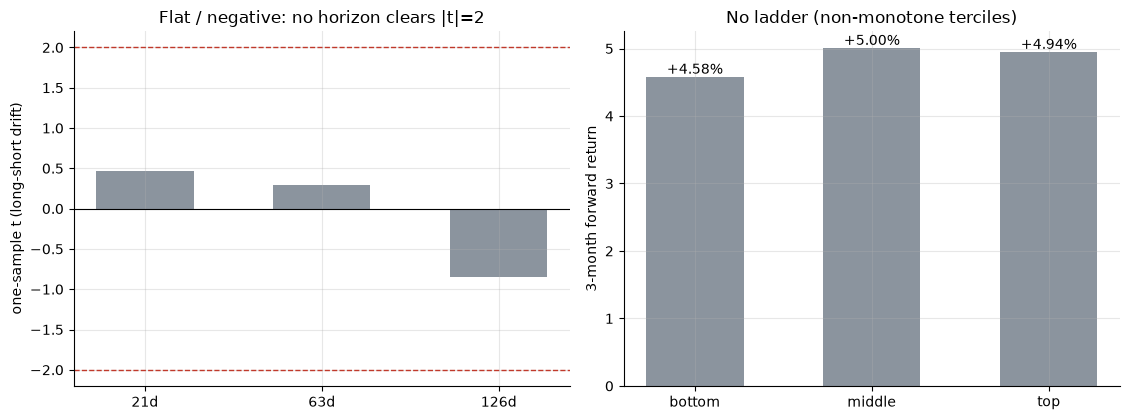

  H= 21d: long-short +0.27%  t=+0.47  win=50%  placebo p=0.305
  H= 63d: long-short +0.37%  t=+0.29  win=51%  placebo p=0.357
  H=126d: long-short -1.68%  t=-0.85  win=51%  placebo p=0.822


In [3]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat / negative: no horizon clears |t|=2')
a2.bar(['bottom','middle','top'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('No ladder (non-monotone terciles)')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift is **flat and then negative** (*t* from +0.47 at 1m to -0.85 at 2q — high ROIC *under*-returns low ROIC over two quarters), the label-shuffle placebo *p* runs 0.31–0.82, and the 63-day terciles are **non-monotone** (+4.58% / +5.00% / +4.94% low→high). The event study and the calendar long-short agree: no return sort.

### 4c · Era split — and the sign flips

Split the calendar long-short at 2018 (the TCJA statutory-rate change).

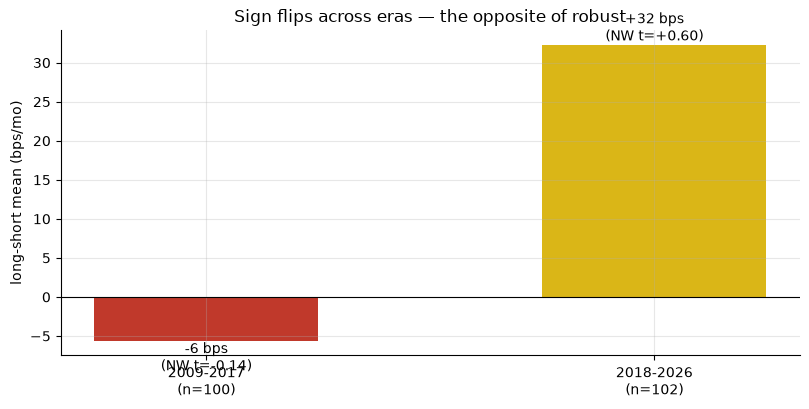

2009-2017: -5.6 bps NW t=-0.14 (n=100)  |  2018-2026: +32.2 bps NW t=+0.60 (n=102)


In [4]:
if HAVE_REAL:
    e = ls[ls.index < '2018-01-01']['ls'].to_numpy(); l = ls[ls.index >= '2018-01-01']['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'2009-2017\n(n={en})', f'2018-2026\n(n={ln})'], [eb, lb], color=[RED, AMBER], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Sign flips across eras — the opposite of robust')
plt.tight_layout(); plt.show()
print(f'2009-2017: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2018-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: -6 bps (NW *t* = -0.14) pre-2018, +32 bps (NW *t* = +0.60) after — the tiny full-sample positive is **entirely a post-2018 artefact**, and the sign is *negative* in the first half. A signal whose sign flips across the sample is not a signal.

### 4d · The headline contrast — does ROIC add anything over ROE / GP?

The *same* calendar long-short on `roic`, plain `roe` (200) and gross profitability `gp` (122), plus the ROIC↔ROE cross-sectional rank correlation.

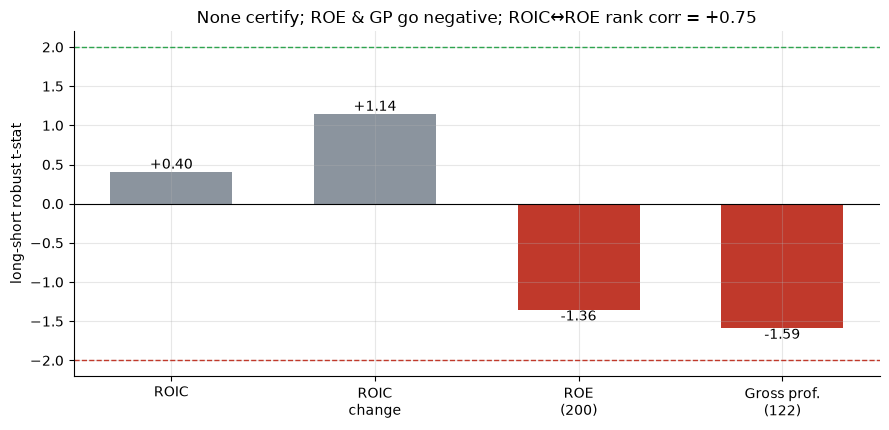

robust t by signal: {'roic': 0.4, 'roic_chg': 1.14, 'roe': -1.36, 'gp': -1.59}  ROIC-ROE rank corr 0.75


In [5]:
if HAVE_REAL:
    c = st.contrast(PX, EV, staleness_days=200)
    order = ['roic','roic_chg','roe','gp']
    ts = [c[k]['t_nw'] for k in order]; rho = c['roic_roe_rank_corr']
else:
    order = ['roic','roic_chg','roe','gp']
    ts = [R['contrast'][k][1] for k in order]; rho = R['roic_roe_rank_corr']
labels = ['ROIC','ROIC\nchange','ROE\n(200)','Gross prof.\n(122)']
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(labels, ts, color=[GREY if t>0 else RED for t in ts], width=.6)
ax.axhline(2, ls='--', c=GREEN, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(ts): ax.annotate(f'{t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('long-short robust t-stat')
ax.set_title(f'None certify; ROE & GP go negative; ROIC↔ROE rank corr = +{rho:.2f}')
plt.tight_layout(); plt.show()
print('robust t by signal:', {k: round(t,2) for k,t in zip(order,ts)}, ' ROIC-ROE rank corr', round(rho,2))

> 💡 In plain words: the headline result. **None** of the quality signals clear the bar; plain ROE (-1.36) and gross profitability (-1.59) are outright **negative** on this panel, and ROIC (+0.40) is only the *least bad*. With a ROIC↔ROE rank correlation of **+0.75**, the unlevered ratio is largely the same bet as ROE. The 'cleaner gauge' refinement earns nothing certifiable here. (ROE and GP run on thinner sub-panels — 89 and 60 months — because fewer names report GrossProfit / positive equity every quarter; read the *signs and magnitudes*, not the literal *t*.)

### 4e · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a sub-0.5 gross *t* already settles it.

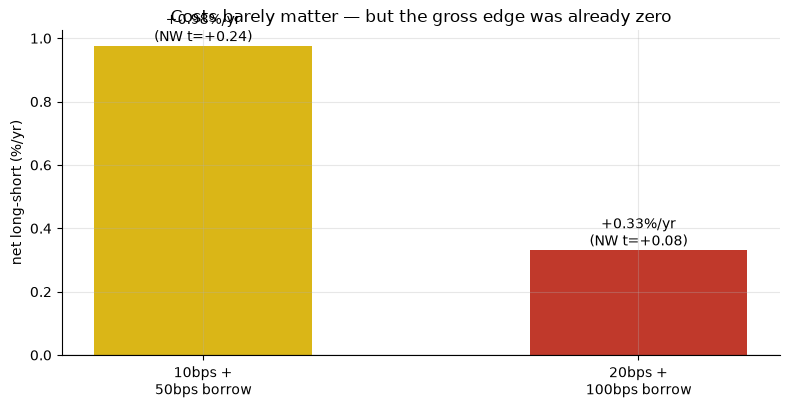

  cost 10bps + borrow 50bps/yr: +0.98%/yr net, NW t=+0.24, Sharpe 0.07
  cost 20bps + borrow 100bps/yr: +0.33%/yr net, NW t=+0.08, Sharpe 0.02


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[AMBER, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'+{a:.2f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Costs barely matter — but the gross edge was already zero')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: +{a:.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is tiny (~0.06/mo — a slow quarterly balance-sheet signal), so costs barely bite; but net NW *t* = +0.08, Sharpe 0.02. You cannot be paid for a spread that was zero to begin with. **Tradability = MIRAGE.**

### 4f · Faithful-engine & power control

Synthetic price + signal panel with a TUNABLE planted premium (high-ROIC names drift up). The null (edge = 0) is checked over **12 seeds**.

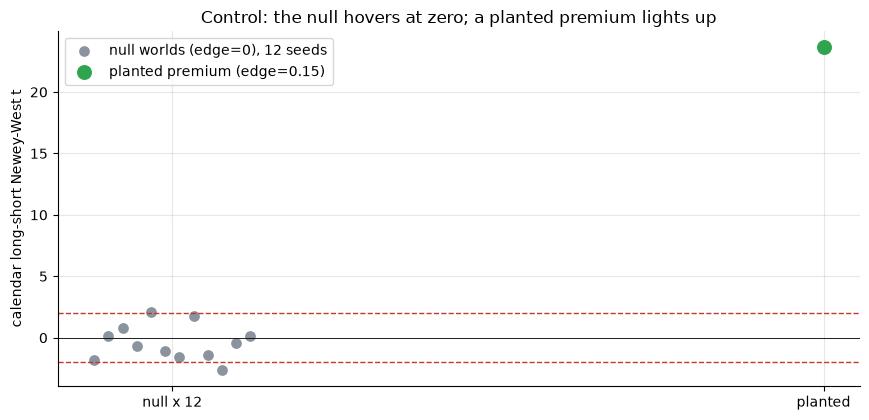

null: mean NW t = -0.38 (sd 1.43), |t|>=2 in 2/12  |  planted NW t = +23.63


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=859 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=859)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted premium (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null hovers at zero; a planted premium lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = -0.38 (sd 1.43), crossing |t|=2 2/12 times (a touch rich for a HAC *t* over ~180 synthetic months, but within noise); a planted premium reads NW *t* = 23.63. The machinery is unbiased and powered, so the real-tape +0.40 is a genuine null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short +13.5 bps/mo (+1.6%/yr gross), one-sample *t* = +0.48, **Newey-West *t* = +0.40**; best specs (staleness-120 +1.12, ROIC-change +1.14) ≪ 2; event drift flat and negative at 2q; era split flips sign. Right-signed by a hair, real by no measure.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: +0.33%/yr, NW *t* = +0.08, Sharpe 0.02; fails before costs.
- **Adds over ROE / GP? `NO`** — ROIC NW *t* +0.40 vs ROE -1.36 vs GP -1.59 (both negative); ROIC↔ROE rank corr +0.75. None certify on mega-cap survivors; ROIC is the least bad and largely the same bet as ROE. The quality premium lives in the junkier cross-section a survivor basket omits.

## 6 · Going further

- **Where the premium lives.** Profitability/quality is strongest in **small, distress-prone** names; a live point-in-time small-cap universe *with the delisted names retained* is where ROIC would get a fair test. This survivor mega-cap panel is the least favourable ground for it — and the short leg is defanged (the true capital-destroyers already left the index).
- **Denominator honesty.** Invested capital uses *long-term* (noncurrent) debt per the study spec; adding short-term borrowings and operating leases would refine the ratio but is unlikely to resurrect a signal this flat.
- **Dedup map:** [200-roe-quality](../../200-roe-quality/) (levered ROE), [122-gross-profitability](../../122-gross-profitability/) (GrossProfit/Assets), [242-quality-minus-junk](../../242-quality-minus-junk/) (the AQR composite), [521-cash-based-operating-profitability](../../521-cash-based-operating-profitability/) (accruals stripped from the numerator). None ranks on NOPAT ÷ invested capital.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*